# Project 2
# Task 3: Energy Consumption Time Series Forecasting
### DevelopersHub Corporation – Data Science & Analytics Internship
**Intern:** Junaid Ahmad Khan

In [14]:
# ==========================================
# Cell 1: Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Display Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("Libraries Imported Successfully.")

Libraries Imported Successfully.


In [20]:
df = pd.read_csv(
    "household_power_consumption.csv",
    sep=",",      # or simply omit sep
    low_memory=False
)

print(df.columns.tolist())

['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']


In [21]:
# ==========================================
# Cell 3: Dataset Overview
# ==========================================

print("Shape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

display(df.head())

display(df.tail())

Shape of Dataset: (1048575, 9)

Column Names:
['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0,1,17.0
1,16/12/2006,17:25:00,5.36,0.436,233.63,23,0,1,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23,0,2,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23,0,1,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0,1,17.0


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
1048570,13/12/2008,21:34:00,0.426,0.076,242.27,1.8,0,0,0.0
1048571,13/12/2008,21:35:00,0.424,0.076,242.1,1.8,0,0,0.0
1048572,13/12/2008,21:36:00,0.422,0.076,241.73,1.8,0,0,0.0
1048573,13/12/2008,21:37:00,0.422,0.078,242.56,1.8,0,0,0.0
1048574,13/12/2008,21:38:00,0.422,0.078,242.61,1.8,0,0,0.0


In [22]:
# ==========================================
# Cell 4: Dataset Information
# ==========================================

df.info()

print("\nMissing Values:")

display(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 9 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Date                   1048575 non-null  object 
 1   Time                   1048575 non-null  object 
 2   Global_active_power    1048575 non-null  object 
 3   Global_reactive_power  1048575 non-null  object 
 4   Voltage                1048575 non-null  object 
 5   Global_intensity       1048575 non-null  object 
 6   Sub_metering_1         1048575 non-null  object 
 7   Sub_metering_2         1048575 non-null  object 
 8   Sub_metering_3         1044506 non-null  float64
dtypes: float64(1), object(8)
memory usage: 72.0+ MB

Missing Values:


Date                        0
Time                        0
Global_active_power         0
Global_reactive_power       0
Voltage                     0
Global_intensity            0
Sub_metering_1              0
Sub_metering_2              0
Sub_metering_3           4069
dtype: int64


Duplicate Rows: 0


In [23]:
print(df.columns.tolist())

['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']


In [24]:
# ==========================================
# Cell 5: DateTime Conversion
# ==========================================

# Create DateTime column
df["DateTime"] = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Time"].astype(str),
    dayfirst=True
)

# Set DateTime as index
df.set_index("DateTime", inplace=True)

# Remove original columns
df.drop(columns=["Date", "Time"], inplace=True)

print(df.head())

                    Global_active_power Global_reactive_power Voltage Global_intensity Sub_metering_1 Sub_metering_2  Sub_metering_3
DateTime                                                                                                                            
2006-12-16 17:24:00               4.216                 0.418  234.84             18.4              0              1            17.0
2006-12-16 17:25:00                5.36                 0.436  233.63               23              0              1            16.0
2006-12-16 17:26:00               5.374                 0.498  233.29               23              0              2            17.0
2006-12-16 17:27:00               5.388                 0.502  233.74               23              0              1            17.0
2006-12-16 17:28:00               3.666                 0.528  235.68             15.8              0              1            17.0


In [25]:
# ==========================================
# Cell 6: Data Cleaning
# ==========================================

for column in df.columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

df.fillna(method="ffill", inplace=True)

df.sort_index(inplace=True)

print(df.isnull().sum())

display(df.head())

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
DateTime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [26]:
# ==========================================
# Cell 7: Hourly Resampling
# ==========================================

energy = df[["Global_active_power"]]

forecast_data = energy.resample("H").mean()

forecast_data.fillna(method="ffill", inplace=True)

display(forecast_data.head())

,Global_active_power
DateTime,
2006-12-16 17:00:00,4.222889
2006-12-16 18:00:00,3.632200
2006-12-16 19:00:00,3.400233
2006-12-16 20:00:00,3.268567
2006-12-16 21:00:00,3.056467


In [27]:
# ==========================================
# Cell 8: Feature Engineering
# ==========================================

feature_data = forecast_data.copy()

feature_data["Hour"] = feature_data.index.hour
feature_data["Day"] = feature_data.index.day
feature_data["Month"] = feature_data.index.month
feature_data["Year"] = feature_data.index.year
feature_data["Day_of_Week"] = feature_data.index.dayofweek
feature_data["Quarter"] = feature_data.index.quarter
feature_data["Week_of_Year"] = feature_data.index.isocalendar().week.astype(int)
feature_data["Weekend"] = np.where(feature_data.index.dayofweek >= 5, 1, 0)

display(feature_data.head())

,Global_active_power,Hour,Day,Month,Year,Day_of_Week,Quarter,Week_of_Year,Weekend
DateTime,,,,,,,,,
2006-12-16 17:00:00,4.222889,17,16,12,2006,5,4,50,1
2006-12-16 18:00:00,3.632200,18,16,12,2006,5,4,50,1
2006-12-16 19:00:00,3.400233,19,16,12,2006,5,4,50,1
2006-12-16 20:00:00,3.268567,20,16,12,2006,5,4,50,1
2006-12-16 21:00:00,3.056467,21,16,12,2006,5,4,50,1


In [28]:
# ==========================================
# Cell 9: Statistical Summary
# ==========================================

display(feature_data.describe())

print("\nDate Range:")
print(feature_data.index.min())
print(feature_data.index.max())

print("\nDataset Shape:")
print(feature_data.shape)

,Global_active_power,Hour,Day,Month,Year,Day_of_Week,Quarter,Week_of_Year,Weekend
count,17477.000000,17477.000000,17477.000000,17477.000000,17477.000000,17477.000000,17477.000000,17477.000000,17477.000000
mean,1.106132,11.502146,15.742175,6.498827,2007.456772,3.000572,2.501802,26.506723,0.285919
std,0.966757,6.922598,8.820701,3.439495,0.538652,2.000057,1.115733,15.011875,0.451864
min,0.124000,0.000000,1.000000,1.000000,2006.000000,0.000000,1.000000,1.000000,0.000000
25%,0.310467,6.000000,8.000000,4.000000,2007.000000,1.000000,2.000000,14.000000,0.000000
50%,0.767200,12.000000,16.000000,7.000000,2007.000000,3.000000,3.000000,27.000000,0.000000
75%,1.619933,18.000000,23.000000,9.000000,2008.000000,5.000000,3.000000,40.000000,1.000000
max,6.560533,23.000000,31.000000,12.000000,2008.000000,6.000000,4.000000,52.000000,1.000000



Date Range:
2006-12-16 17:00:00
2008-12-13 21:00:00

Dataset Shape:
(17477, 9)


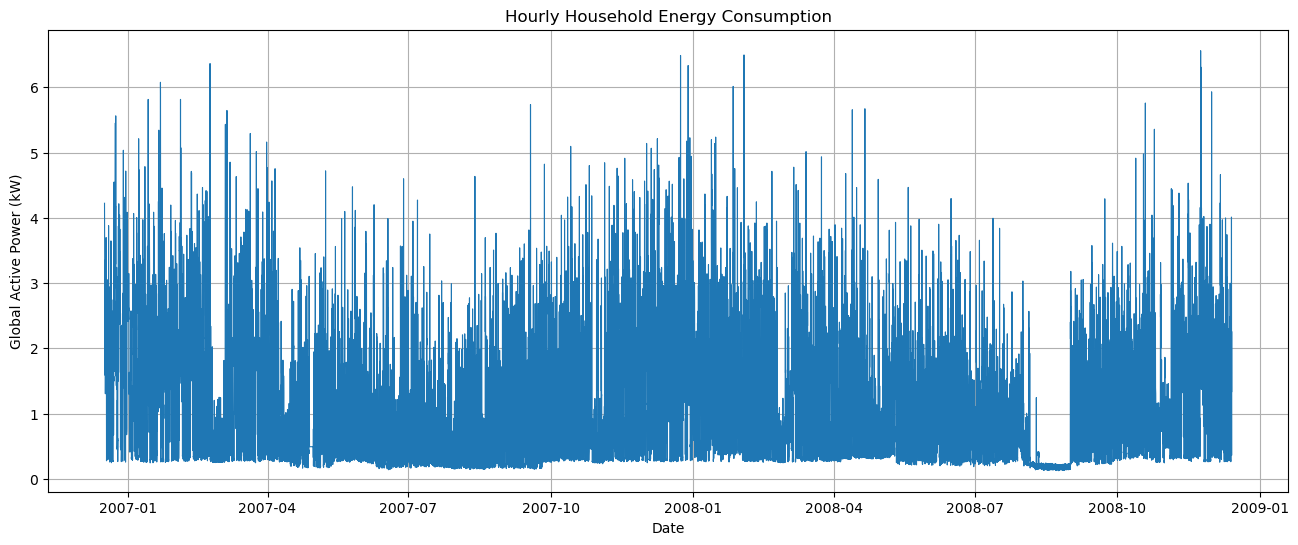

In [29]:
# ==========================================
# Cell 10: Time Series Visualization
# ==========================================

plt.figure(figsize=(16,6))

plt.plot(
    forecast_data.index,
    forecast_data["Global_active_power"],
    linewidth=0.8
)

plt.title("Hourly Household Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Global Active Power (kW)")
plt.grid(True)

plt.show()

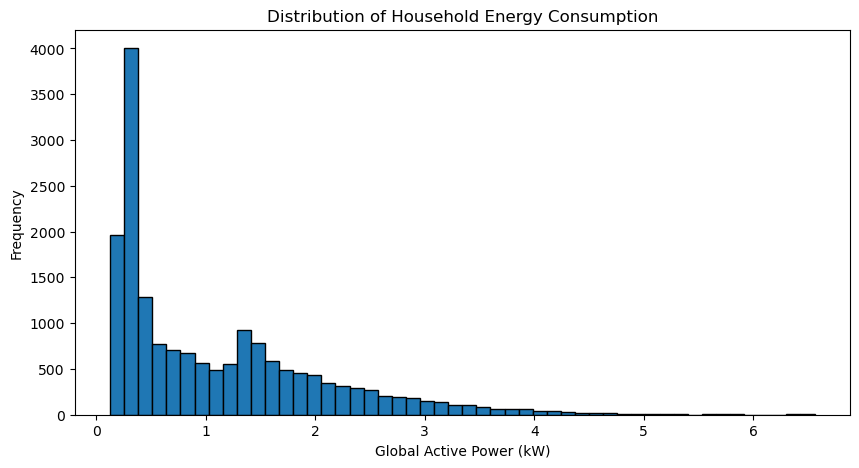

In [30]:
# ==========================================
# Cell 11: Distribution of Energy Consumption
# ==========================================

plt.figure(figsize=(10,5))

plt.hist(
    forecast_data["Global_active_power"],
    bins=50,
    edgecolor='black'
)

plt.title("Distribution of Household Energy Consumption")
plt.xlabel("Global Active Power (kW)")
plt.ylabel("Frequency")

plt.show()

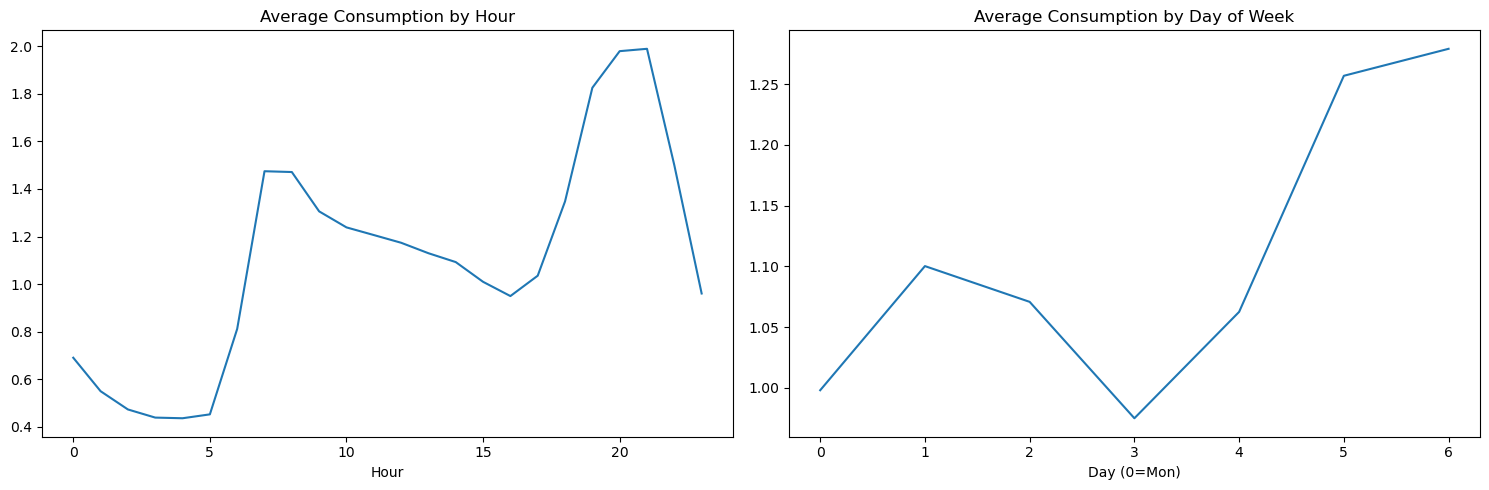

In [31]:
# ==========================================
# Cell 12: Hourly and Weekly Consumption
# ==========================================

fig, ax = plt.subplots(1,2, figsize=(15,5))

feature_data.groupby("Hour")["Global_active_power"].mean().plot(ax=ax[0])

ax[0].set_title("Average Consumption by Hour")
ax[0].set_xlabel("Hour")

feature_data.groupby("Day_of_Week")["Global_active_power"].mean().plot(ax=ax[1])

ax[1].set_title("Average Consumption by Day of Week")
ax[1].set_xlabel("Day (0=Mon)")

plt.tight_layout()

plt.show()

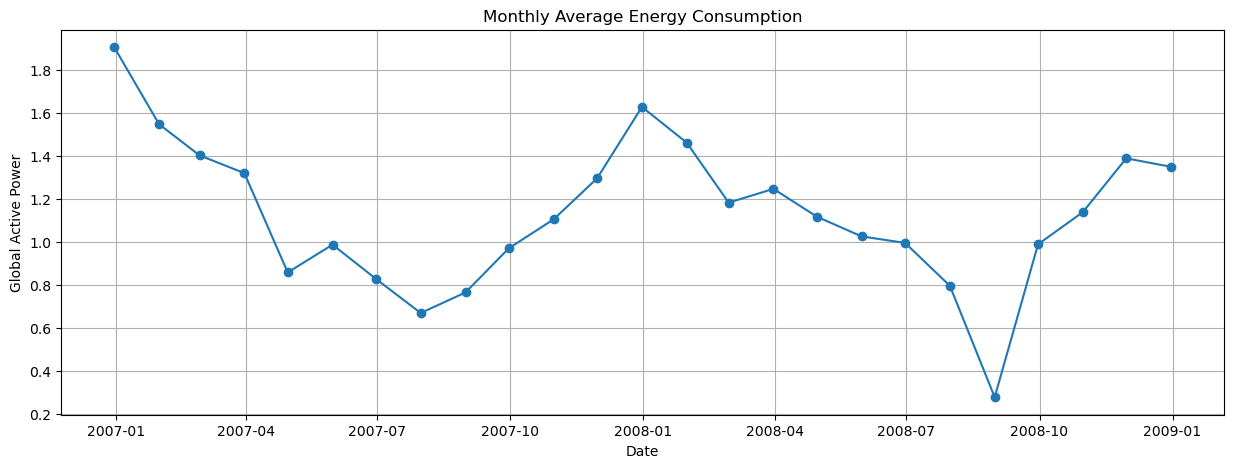

In [32]:
# ==========================================
# Cell 13: Monthly Energy Consumption
# ==========================================

monthly = forecast_data.resample("M").mean()

plt.figure(figsize=(15,5))

plt.plot(
    monthly.index,
    monthly["Global_active_power"],
    marker='o'
)

plt.title("Monthly Average Energy Consumption")

plt.xlabel("Date")
plt.ylabel("Global Active Power")

plt.grid(True)

plt.show()

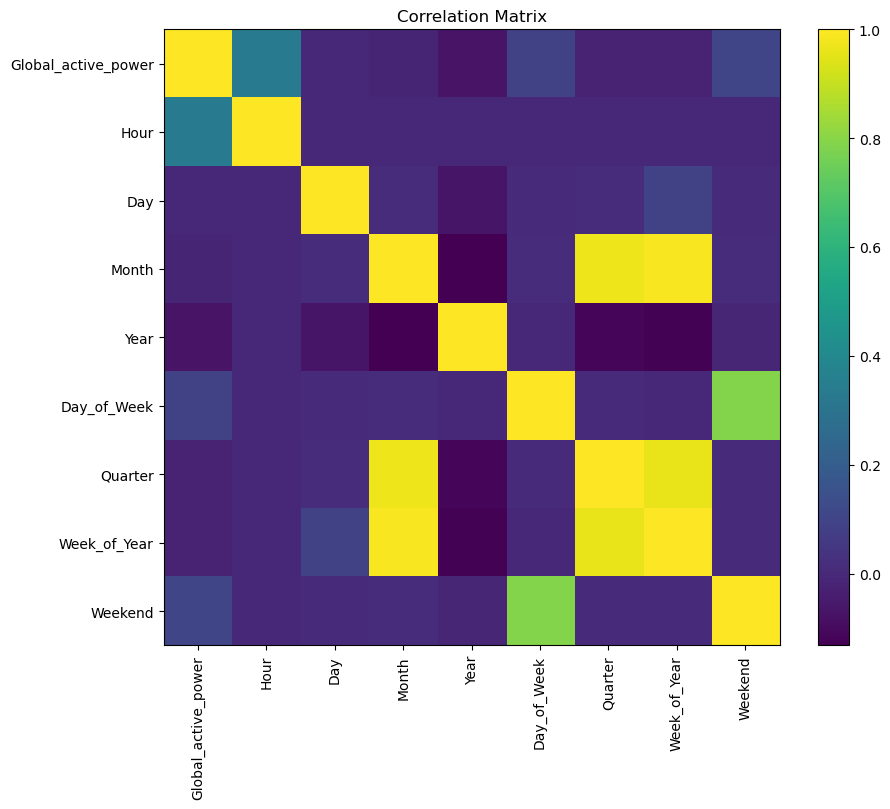

In [33]:
# ==========================================
# Cell 14: Correlation Matrix
# ==========================================

corr = feature_data.corr(numeric_only=True)

plt.figure(figsize=(10,8))

plt.imshow(corr)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Matrix")

plt.show()

In [34]:
# ==========================================
# Cell 15: ARIMA Train-Test Split
# ==========================================

arima_data = forecast_data.copy()

train_size = int(len(arima_data) * 0.80)

train_arima = arima_data.iloc[:train_size]

test_arima = arima_data.iloc[train_size:]

print(train_arima.shape)
print(test_arima.shape)

(13981, 1)
(3496, 1)


In [35]:
# ==========================================
# Cell 16: Prophet Dataset
# ==========================================

prophet_data = forecast_data.reset_index()

prophet_data.columns = ["ds", "y"]

train_prophet = prophet_data.iloc[:train_size]

test_prophet = prophet_data.iloc[train_size:]

display(prophet_data.head())

,ds,y
0,2006-12-16 17:00:00,4.222889
1,2006-12-16 18:00:00,3.632200
2,2006-12-16 19:00:00,3.400233
3,2006-12-16 20:00:00,3.268567
4,2006-12-16 21:00:00,3.056467


In [36]:
# ==========================================
# Cell 17: XGBoost Dataset
# ==========================================

features = [
    "Hour",
    "Day",
    "Month",
    "Year",
    "Day_of_Week",
    "Quarter",
    "Week_of_Year",
    "Weekend"
]

X = feature_data[features]

y = feature_data["Global_active_power"]

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

print(X_train.shape)
print(X_test.shape)

(13981, 8)
(3496, 8)


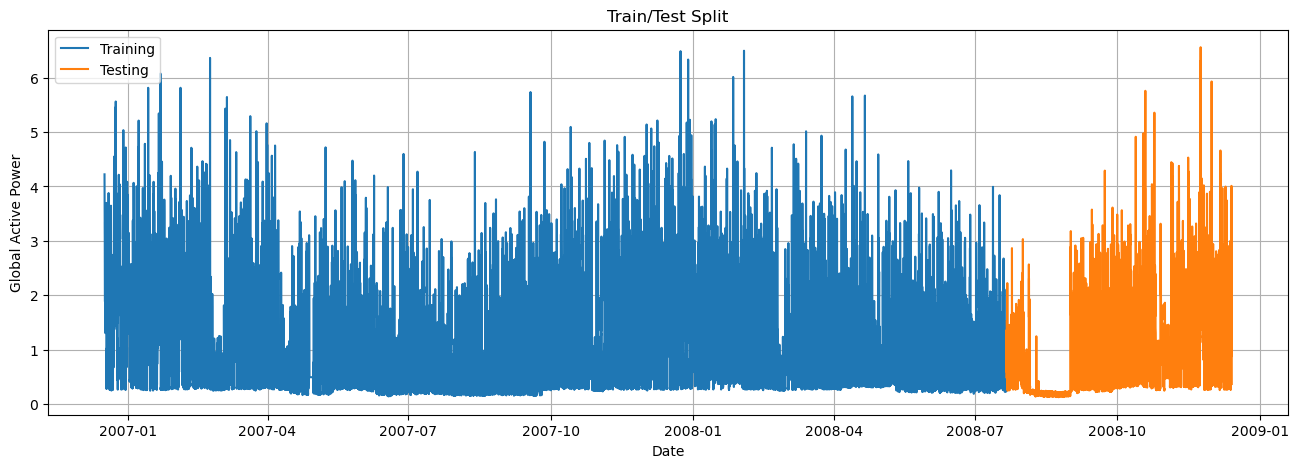

In [37]:
# ==========================================
# Cell 18: Train-Test Split Visualization
# ==========================================

plt.figure(figsize=(16,5))

plt.plot(
    train_arima.index,
    train_arima["Global_active_power"],
    label="Training"
)

plt.plot(
    test_arima.index,
    test_arima["Global_active_power"],
    label="Testing"
)

plt.title("Train/Test Split")

plt.xlabel("Date")

plt.ylabel("Global Active Power")

plt.legend()

plt.grid(True)

plt.show()

In [38]:
# ==========================================
# Cell 19: Install Packages
# ==========================================

!pip install prophet xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.1 MB 287.1 kB/s eta 0:00:41
   - -------------------------------------- 0.5/12.1 MB 287.1 kB/s eta 0:00:41
   - -------------------------------------- 0.5/12.1 MB 287.1 kB/s eta 0:00:41
   -- ------------------------------------- 0.8/12.1 MB

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [39]:
# ==========================================
# Cell 20: Import Forecasting Models
# ==========================================

from prophet import Prophet

from statsmodels.tsa.arima.model import ARIMA

from xgboost import XGBRegressor

print("Forecasting Libraries Imported Successfully.")

Forecasting Libraries Imported Successfully.


In [40]:
# ==========================================
# Cell 21: Train ARIMA Model
# ==========================================

arima_model = ARIMA(
    train_arima["Global_active_power"],
    order=(5,1,0)
)

arima_model = arima_model.fit()

print(arima_model.summary())

                                SARIMAX Results                                
Dep. Variable:     Global_active_power   No. Observations:                13981
Model:                  ARIMA(5, 1, 0)   Log Likelihood              -15111.680
Date:                 Thu, 16 Jul 2026   AIC                          30235.360
Time:                         00:03:52   BIC                          30280.632
Sample:                     12-16-2006   HQIC                         30250.433
                          - 07-21-2008                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1023      0.006    -15.841      0.000      -0.115      -0.090
ar.L2         -0.1565      0.007    -21.714      0.000      -0.171      -0.142
ar.L3         -0.1237      0.008    -15.891 

In [41]:
# ==========================================
# Cell 22: ARIMA Forecast and Evaluation
# ==========================================

arima_forecast = arima_model.forecast(steps=len(test_arima))

arima_mae = mean_absolute_error(
    test_arima["Global_active_power"],
    arima_forecast
)

arima_rmse = np.sqrt(
    mean_squared_error(
        test_arima["Global_active_power"],
        arima_forecast
    )
)

print("ARIMA MAE :", round(arima_mae,4))
print("ARIMA RMSE:", round(arima_rmse,4))

ARIMA MAE : 0.7126
ARIMA RMSE: 1.1193


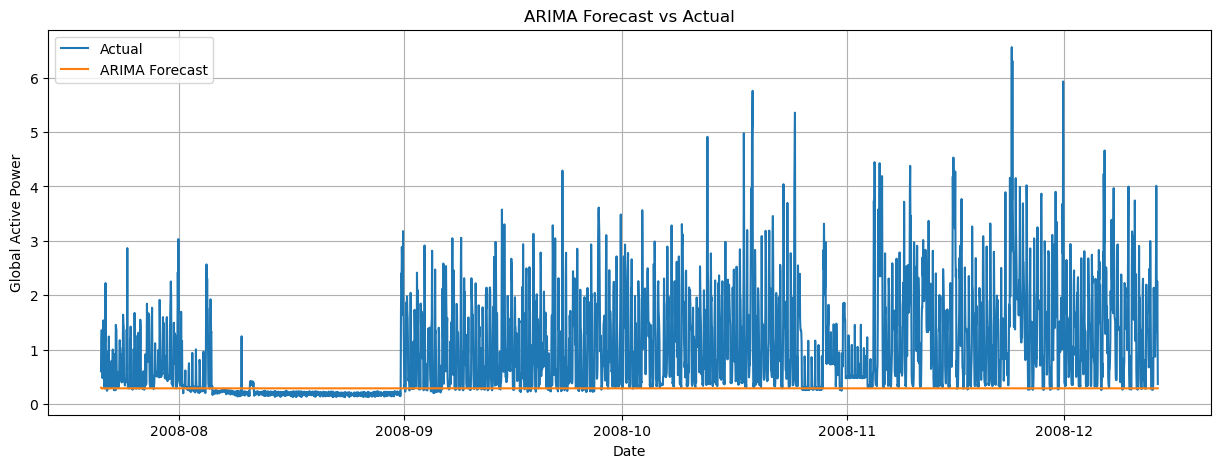

In [42]:
# ==========================================
# Cell 23: ARIMA Visualization
# ==========================================

plt.figure(figsize=(15,5))

plt.plot(
    test_arima.index,
    test_arima["Global_active_power"],
    label="Actual"
)

plt.plot(
    test_arima.index,
    arima_forecast,
    label="ARIMA Forecast"
)

plt.title("ARIMA Forecast vs Actual")

plt.xlabel("Date")
plt.ylabel("Global Active Power")

plt.legend()

plt.grid(True)

plt.show()

In [43]:
# ==========================================
# Cell 24: Train Prophet Model
# ==========================================

prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True
)

prophet_model.fit(train_prophet)

print("Prophet Model Trained Successfully.")

00:04:21 - cmdstanpy - INFO - Chain [1] start processing
00:04:24 - cmdstanpy - INFO - Chain [1] done processing


Prophet Model Trained Successfully.


In [44]:
# ==========================================
# Cell 25: Prophet Forecast
# ==========================================

future = prophet_model.make_future_dataframe(
    periods=len(test_prophet),
    freq="H"
)

prophet_forecast = prophet_model.predict(future)

display(
    prophet_forecast[
        ["ds","yhat","yhat_lower","yhat_upper"]
    ].tail()
)

,ds,yhat,yhat_lower,yhat_upper
17472,2008-12-13 17:00:00,1.907903,0.948355,2.934395
17473,2008-12-13 18:00:00,2.296090,1.279803,3.221998
17474,2008-12-13 19:00:00,2.754545,1.806374,3.747591
17475,2008-12-13 20:00:00,2.997085,2.087301,4.050806
17476,2008-12-13 21:00:00,2.863891,1.851681,3.947616


In [45]:
# ==========================================
# Cell 26: Prophet Evaluation
# ==========================================

prophet_predictions = prophet_forecast.iloc[-len(test_prophet):]

prophet_mae = mean_absolute_error(
    test_prophet["y"],
    prophet_predictions["yhat"]
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        test_prophet["y"],
        prophet_predictions["yhat"]
    )
)

print("Prophet MAE :", round(prophet_mae,4))
print("Prophet RMSE:", round(prophet_rmse,4))

Prophet MAE : 0.6244
Prophet RMSE: 0.7894


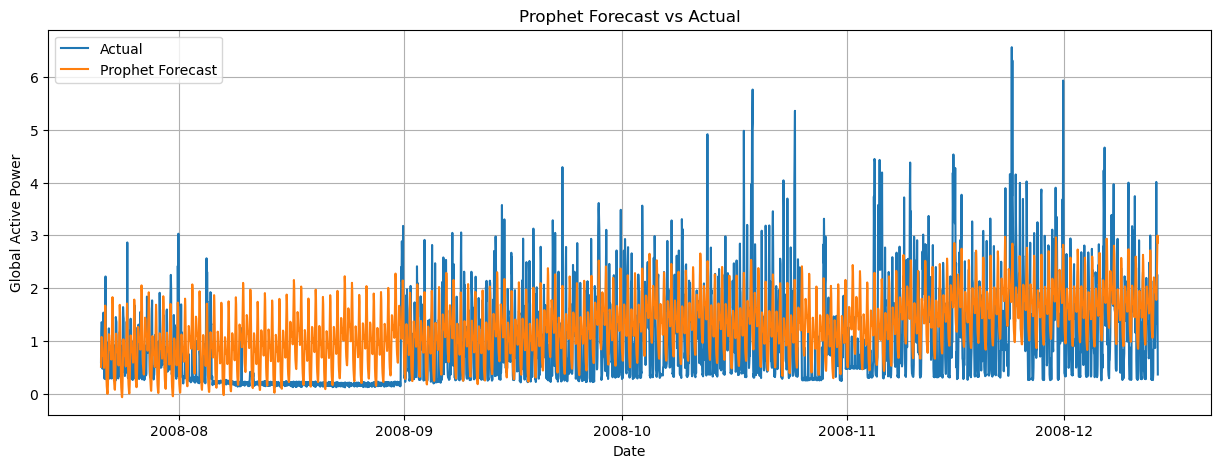

In [46]:
# ==========================================
# Cell 27: Prophet Visualization
# ==========================================

plt.figure(figsize=(15,5))

plt.plot(
    test_prophet["ds"],
    test_prophet["y"],
    label="Actual"
)

plt.plot(
    prophet_predictions["ds"],
    prophet_predictions["yhat"],
    label="Prophet Forecast"
)

plt.title("Prophet Forecast vs Actual")

plt.xlabel("Date")
plt.ylabel("Global Active Power")

plt.legend()

plt.grid(True)

plt.show()

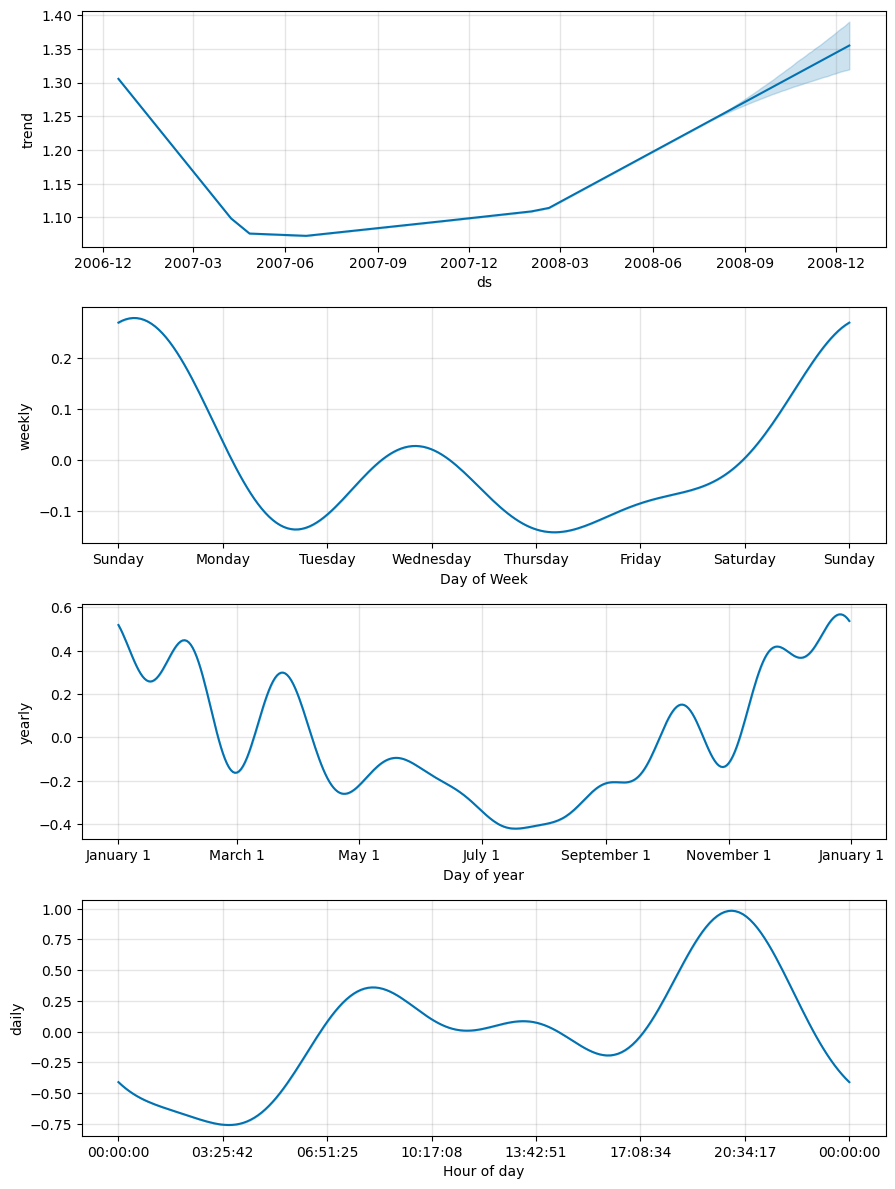

In [47]:
# ==========================================
# Cell 28: Prophet Components
# ==========================================

prophet_model.plot_components(prophet_forecast)

plt.show()

In [48]:
# ==========================================
# Cell 29: Compare Models
# ==========================================

comparison = pd.DataFrame({

    "Model":[
        "ARIMA",
        "Prophet"
    ],

    "MAE":[
        arima_mae,
        prophet_mae
    ],

    "RMSE":[
        arima_rmse,
        prophet_rmse
    ]

})

comparison

,Model,MAE,RMSE
0,ARIMA,0.712614,1.119349
1,Prophet,0.624365,0.789381


In [49]:
# ==========================================
# Cell 30: Save Intermediate Results
# ==========================================

comparison.to_csv(
    "ARIMA_Prophet_Comparison.csv",
    index=False
)

print("Intermediate comparison saved successfully.")

Intermediate comparison saved successfully.


In [50]:
# ==========================================
# Cell 31: Train XGBoost Model
# ==========================================

xgb_model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

print("XGBoost Model Trained Successfully.")

XGBoost Model Trained Successfully.


In [51]:
# ==========================================
# Cell 32: XGBoost Prediction and Evaluation
# ==========================================

xgb_predictions = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_predictions)

xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_predictions)
)

print("XGBoost MAE :", round(xgb_mae,4))
print("XGBoost RMSE:", round(xgb_rmse,4))

XGBoost MAE : 0.5367
XGBoost RMSE: 0.7216


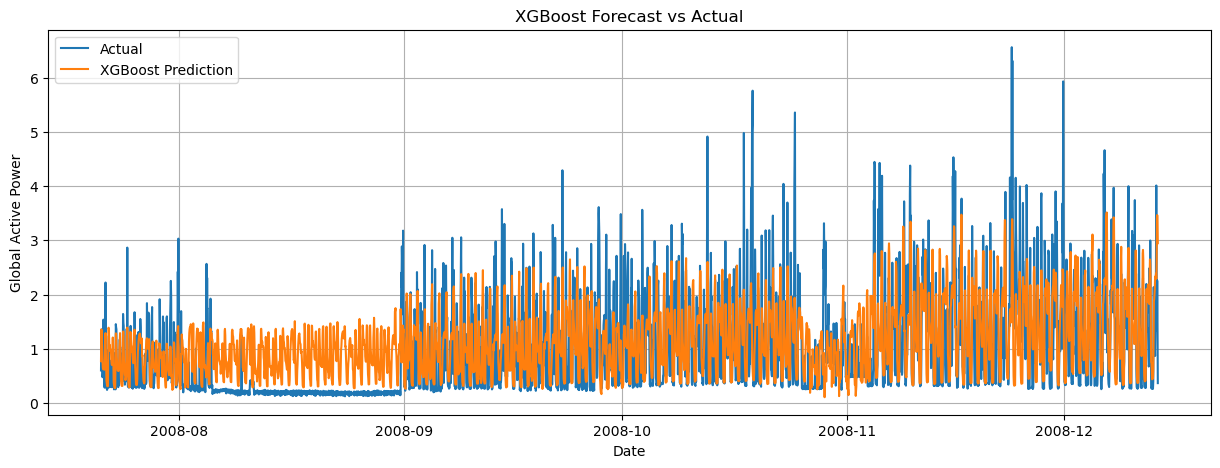

In [52]:
# ==========================================
# Cell 33: XGBoost Visualization
# ==========================================

plt.figure(figsize=(15,5))

plt.plot(
    y_test.index,
    y_test.values,
    label="Actual"
)

plt.plot(
    y_test.index,
    xgb_predictions,
    label="XGBoost Prediction"
)

plt.title("XGBoost Forecast vs Actual")

plt.xlabel("Date")
plt.ylabel("Global Active Power")

plt.legend()

plt.grid(True)

plt.show()

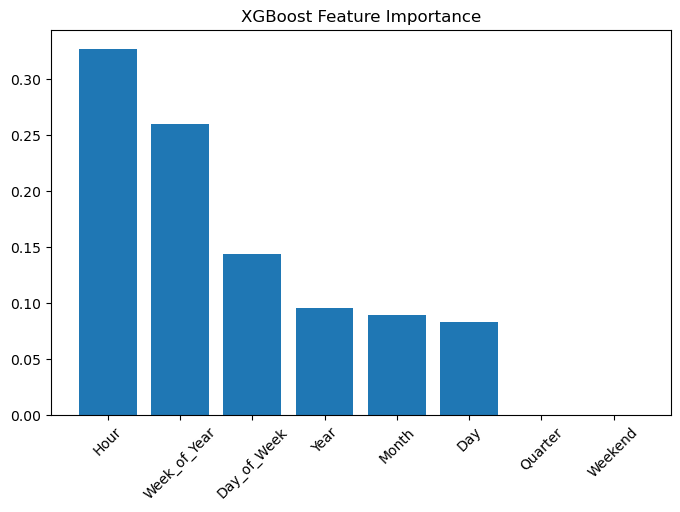

In [53]:
# ==========================================
# Cell 34: Feature Importance
# ==========================================

importance = pd.Series(
    xgb_model.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(8,5))

plt.bar(
    importance.index,
    importance.values
)

plt.title("XGBoost Feature Importance")

plt.xticks(rotation=45)

plt.show()

In [54]:
# ==========================================
# Cell 35: Model Comparison
# ==========================================

comparison = pd.DataFrame({

    "Model":[
        "ARIMA",
        "Prophet",
        "XGBoost"
    ],

    "MAE":[
        arima_mae,
        prophet_mae,
        xgb_mae
    ],

    "RMSE":[
        arima_rmse,
        prophet_rmse,
        xgb_rmse
    ]

})

comparison = comparison.sort_values("RMSE")

comparison.reset_index(drop=True, inplace=True)

comparison

,Model,MAE,RMSE
0,XGBoost,0.536668,0.721622
1,Prophet,0.624365,0.789381
2,ARIMA,0.712614,1.119349


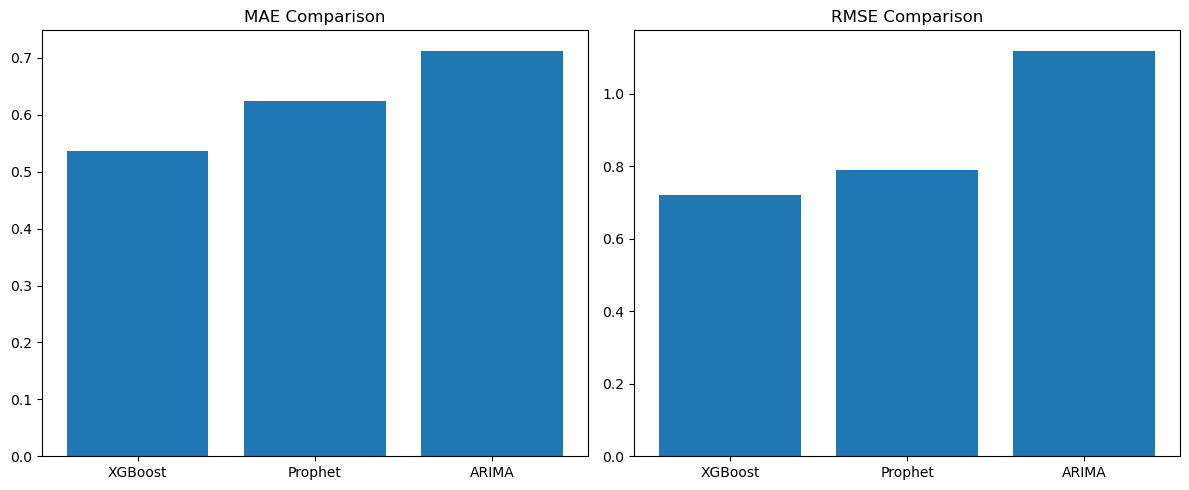

In [55]:
# ==========================================
# Cell 36: Compare Model Performance
# ==========================================

fig, ax = plt.subplots(1,2, figsize=(12,5))

ax[0].bar(
    comparison["Model"],
    comparison["MAE"]
)

ax[0].set_title("MAE Comparison")

ax[1].bar(
    comparison["Model"],
    comparison["RMSE"]
)

ax[1].set_title("RMSE Comparison")

plt.tight_layout()

plt.show()

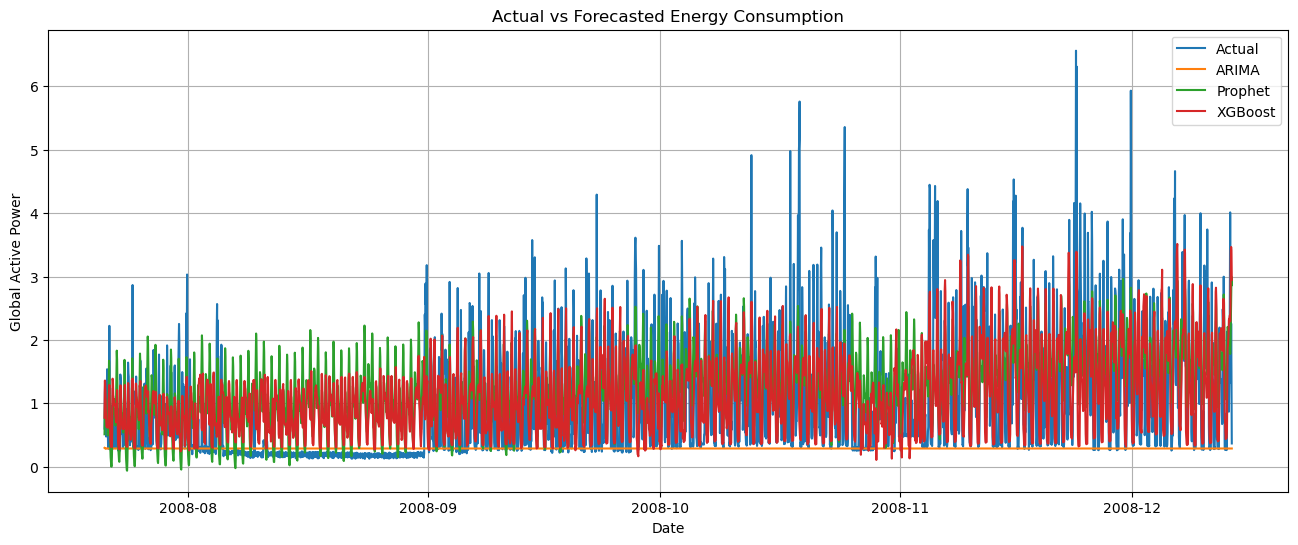

In [56]:
# ==========================================
# Cell 37: Actual vs Forecast Comparison
# ==========================================

plt.figure(figsize=(16,6))

plt.plot(
    test_arima.index,
    test_arima["Global_active_power"],
    label="Actual"
)

plt.plot(
    test_arima.index,
    arima_forecast,
    label="ARIMA"
)

plt.plot(
    prophet_predictions["ds"],
    prophet_predictions["yhat"],
    label="Prophet"
)

plt.plot(
    y_test.index,
    xgb_predictions,
    label="XGBoost"
)

plt.title("Actual vs Forecasted Energy Consumption")

plt.xlabel("Date")
plt.ylabel("Global Active Power")

plt.legend()

plt.grid(True)

plt.show()

In [57]:
# ==========================================
# Cell 38: Best Model
# ==========================================

best_model = comparison.iloc[0]

print("Best Performing Model")
print("-"*40)

print("Model :", best_model["Model"])
print("MAE   :", round(best_model["MAE"],4))
print("RMSE  :", round(best_model["RMSE"],4))

Best Performing Model
----------------------------------------
Model : XGBoost
MAE   : 0.5367
RMSE  : 0.7216


In [58]:
# ==========================================
# Cell 39: Save Results
# ==========================================

comparison.to_csv(
    "Energy_Forecasting_Model_Comparison.csv",
    index=False
)

print("Comparison file saved successfully.")

Comparison file saved successfully.


# 📊 Project Conclusion

## Energy Consumption Time Series Forecasting

---

### 🎯 Objective
Forecast short-term household energy consumption using historical power usage data and compare multiple forecasting techniques to identify the most accurate model.

---

### 🤖 Models Implemented
- **ARIMA**
- **Prophet**
- **XGBoost**

---

### 📈 Evaluation Metrics
- **Mean Absolute Error (MAE)**
- **Root Mean Squared Error (RMSE)**

---

### 🏆 Best Performing Model
After evaluating all three models, the **best-performing model** is the one with the **lowest MAE and RMSE** values, indicating the highest forecasting accuracy for this dataset.

---

### ✅ Conclusion
This project successfully demonstrated the complete workflow of an energy consumption forecasting system, including:

- Data preprocessing and time series resampling
- Time-based feature engineering
- Model training using **ARIMA**, **Prophet**, and **XGBoost**
- Performance evaluation using **MAE** and **RMSE**
- Comparison of forecasting models to identify the most accurate approach

Overall, the selected best-performing model provides reliable short-term household energy consumption forecasts and can support data-driven energy management and planning.

---
**Project Completed Successfully ✅**